# 선문대학교 컴퓨터공학부
# 2022243101 최완우

## 타이타닉

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# 타이타닉 CSV 파일 불러오기
titanic = pd.read_csv('3.1.titanic.csv')


In [12]:
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [13]:
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [14]:
titanic = pd.read_csv('3.1.titanic.csv')

# 객실 등급에 따른 생존자와 사망자의 평균 계산
pclass_survived_mean = titanic.groupby('Pclass')['Survived'].mean().reset_index()
pclass_survived_mean


,Pclass,Survived
0,1,0.629630
1,2,0.472826
2,3,0.242363


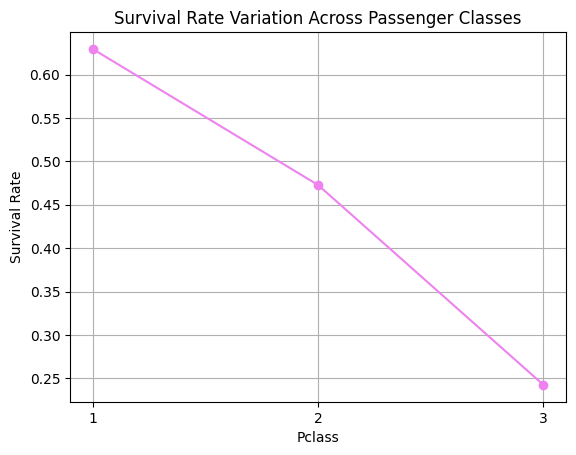

In [15]:
# 선 그래프 그리기
plt.plot(pclass_survived_mean['Pclass'], pclass_survived_mean['Survived'], marker='o', linestyle='-', color='violet')
plt.title('Survival Rate Variation Across Passenger Classes')
plt.xlabel('Pclass')
plt.ylabel('Survival Rate')
plt.xticks([1, 2, 3])
plt.grid(True)
plt.show()

In [16]:
# 승선 항구에 따른 생존자의 수 계산
survived_counts = titanic[titanic['Survived'] == 1]['Embarked'].value_counts()
survived_counts


Embarked
S    217
C     93
Q     30
Name: count, dtype: int64

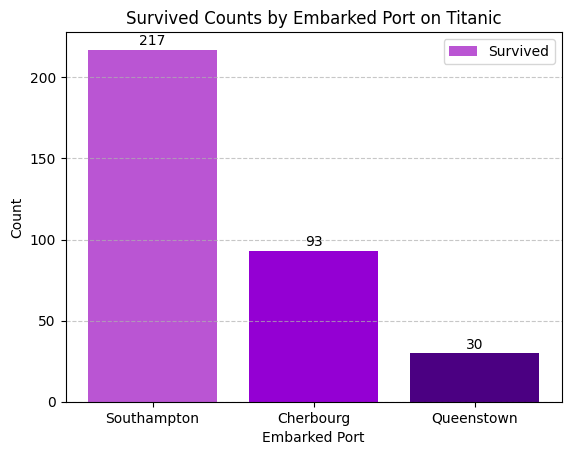

In [18]:
# 막대 그래프 그리기
plt.bar(survived_counts.index, survived_counts, color = ['mediumorchid', 'darkviolet', 'indigo'])
plt.title('Survived Counts by Embarked Port on Titanic')
plt.xlabel('Embarked Port')
plt.ylabel('Count')
plt.xticks(survived_counts.index, ['Southampton', 'Cherbourg', 'Queenstown'])
plt.legend(['Survived'], loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 생존자 수 표시
for i, value in enumerate(survived_counts):
  plt.text(i, value + 1, str(value), ha='center', va='bottom')
plt.show()


In [19]:
# 성별에 따른 생존자의 수 계산
survived_counts = titanic[titanic['Survived'] == 1]['Sex'].value_counts()
survived_counts


Sex
female    233
male      109
Name: count, dtype: int64

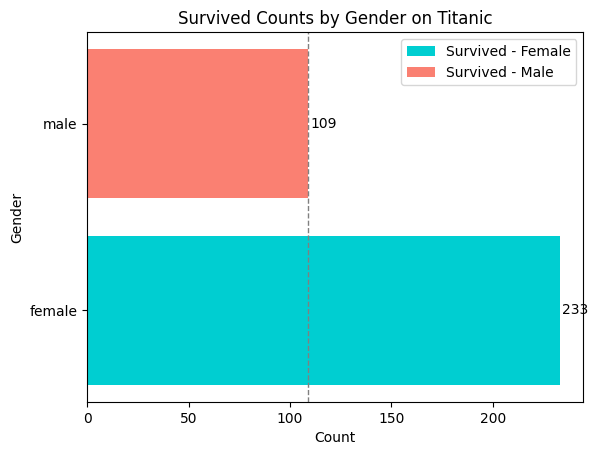

In [21]:
bars = plt.barh(survived_counts.index, survived_counts, color=['darkturquoise', 'salmon'])
plt.title('Survived Counts by Gender on Titanic')
plt.xlabel('Count')
plt.ylabel('Gender')
plt.legend(bars, ['Survived - Female', 'Survived - Male'], loc='upper right')

# 차이 강조를 위해 수평선 추가
plt.axvline(x=survived_counts['male'], color='gray', linestyle='--', linewidth=1)

# 생존자 수 표시
for i, value in enumerate(survived_counts):
  plt.text(value + 1, i, str(value), ha='left', va='center')
plt.show()


In [22]:
print(titanic.info(), '\n')

# 결측치 처리
titanic = titanic.dropna(subset=['Age', 'Fare', 'Survived'])
print(titanic.info())


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
None 

<class 'pandas.DataFrame'>
Index: 714 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  714 non-null    int64  
 1   Survived     714 non-null    int

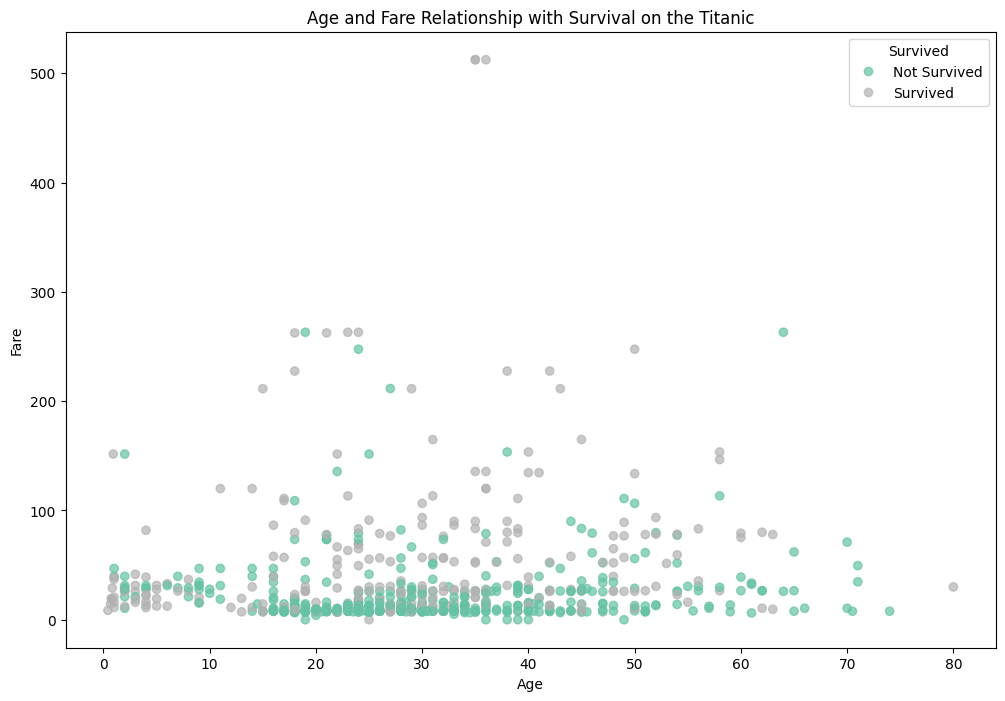

In [24]:
plt.figure(figsize=(12, 8))
scatter = plt.scatter(x='Age', y='Fare', data=titanic, c=titanic['Survived'], cmap='Set2', alpha=0.7)

plt.title('Age and Fare Relationship with Survival on the Titanic')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.legend(handles=scatter.legend_elements()[0], title='Survived', labels=['Not Survived', 'Survived'], loc='upper right')
plt.show()

In [25]:
# 사망자와 생존자의 수 계산
survived_counts = titanic['Survived'].value_counts()
survived_counts


Survived
0    424
1    290
Name: count, dtype: int64

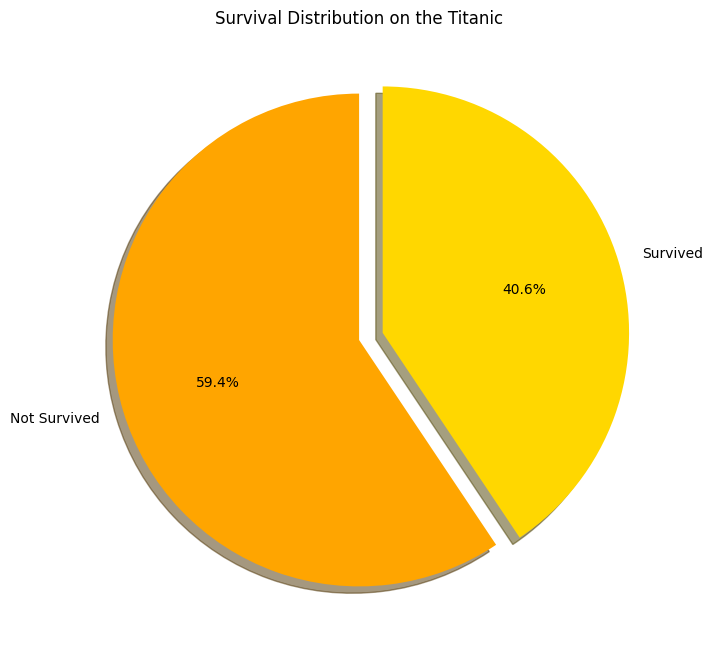

In [26]:
plt.figure(figsize=(8, 8))
plt.pie(survived_counts, labels=['Not Survived', 'Survived'], colors=['orange', 'gold'],
        	   autopct='%0.1f%%', startangle=90, shadow=True, explode=(0, 0.1))

plt.title('Survival Distribution on the Titanic')
plt.show()
